**FORMACIÓN DEL BIOFILM (1 BACTERIA)**

*time-lapse*

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import display, clear_output
import time
from numba import njit


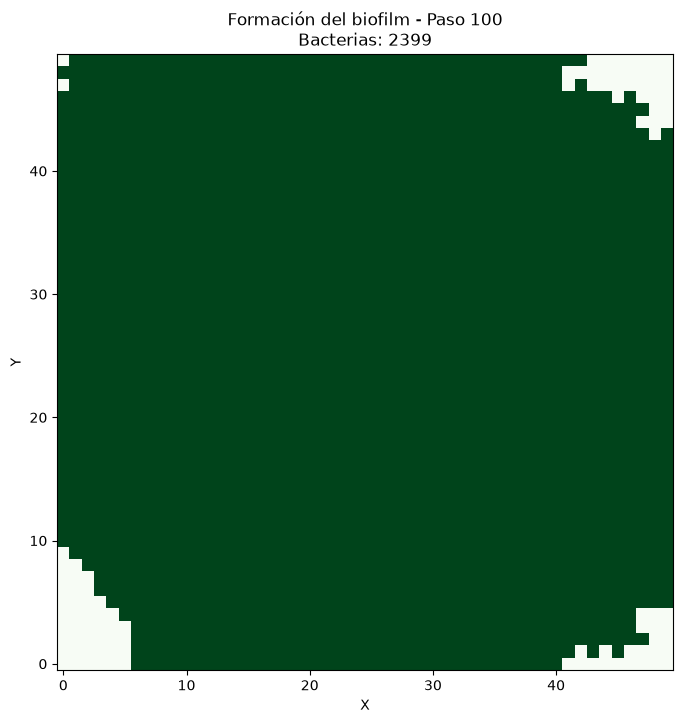

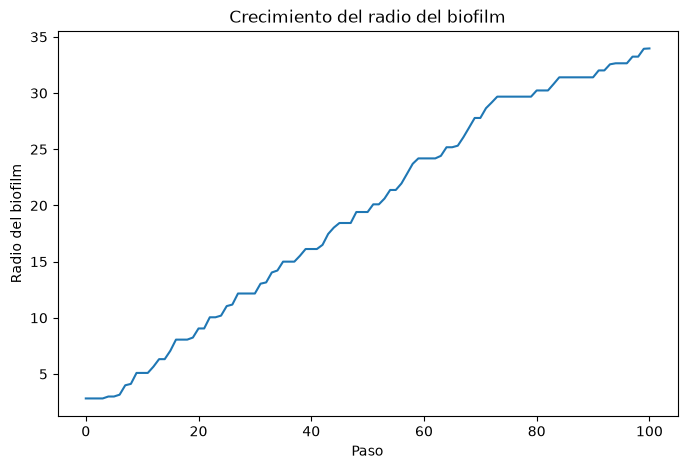

In [2]:
l = 50
b_0 = 5
div_prob = 0.3
steps = 100


lattice = np.zeros((l, l), dtype=int)
center = l // 2

for i in range(b_0):
    x = center + random.randint(-2, 2)
    y = center + random.randint(-2, 2)
    while lattice[x, y] == 1:
        x = center + random.randint(-2, 2)
        y = center + random.randint(-2, 2)
    lattice[x, y] = 1


@njit
def get_neighbors(x, y):
    neighbors = []
    if x > 0:
        neighbors.append((x - 1, y))
    if x < l - 1:
        neighbors.append((x + 1, y))
    if y > 0:
        neighbors.append((x, y - 1))
    if y < l - 1:
        neighbors.append((x, y + 1))
    return neighbors

@njit
def growth(lattice, div_prob, blocked_bacteria):
    bacteria_positions = list(zip(*np.where(lattice == 1)))
    random.shuffle(bacteria_positions)
    for x, y in bacteria_positions:
        if (x, y) in blocked_bacteria:
            continue

        neighbors = get_neighbors(x, y)

        free_pos = [(nx, ny) for nx, ny in neighbors if lattice[nx, ny] == 0]
        if len(free_pos) == 0:
            blocked_bacteria.add((x, y))
            continue
        if random.random() < div_prob:
            daughter_x, daughter_y = random.choice(free_pos)
            lattice[daughter_x, daughter_y] = 1

lattice_history = []
blocked_bacteria = set()

for step in range(steps + 1): 

    clear_output(wait=True)
    lattice_history.append(lattice.copy())

    plt.figure(figsize=(8, 8))

    plt.imshow(lattice, origin="lower", cmap="Greens", vmin=0, vmax=1)

    plt.xlim(-0.5, l - 0.5)
    plt.ylim(-0.5, l - 0.5)

    plt.title( 
        f"Formación del biofilm - Paso {step}\n" 
        f"Bacterias: {np.sum(lattice)}" 
    ) 
    plt.xlabel("X") 
    plt.ylabel("Y") 
    plt.show()

    time.sleep(0.05)
    if step == steps:
        break

    bacteria_positions = list(zip(*np.where(lattice == 1))) 
    random.shuffle(bacteria_positions) 
    for x, y in bacteria_positions: 
        if (x, y) in blocked_bacteria:
            continue

        neighbors = get_neighbors(x, y)

        free_pos = [(nx, ny) for nx, ny in neighbors if lattice[nx, ny] == 0]
        if len(free_pos) == 0:
            blocked_bacteria.add((x, y))
            continue
        if random.random() < div_prob:
            daughter_x, daughter_y = random.choice(free_pos)
            lattice[daughter_x, daughter_y] = 1
      
@njit
def calculate_radius(lattice):
    bacteria_positions = np.argwhere(lattice == 1)

    if len(bacteria_positions) == 0:
        return 0

    distances = []

    for x, y in bacteria_positions:
        distance = np.sqrt((x - center)**2 + (y - center)**2)
        distances.append(distance)

    return max(distances)

radius_history = []
for lattice_steps in lattice_history:

    radius = calculate_radius(lattice_steps)
    radius_history.append(radius)

plt.figure(figsize=(8, 5))

plt.plot(range(step + 1), radius_history)

plt.xlabel("Paso")
plt.ylabel("Radio del biofilm")
plt.title("Crecimiento del radio del biofilm")

plt.show()   

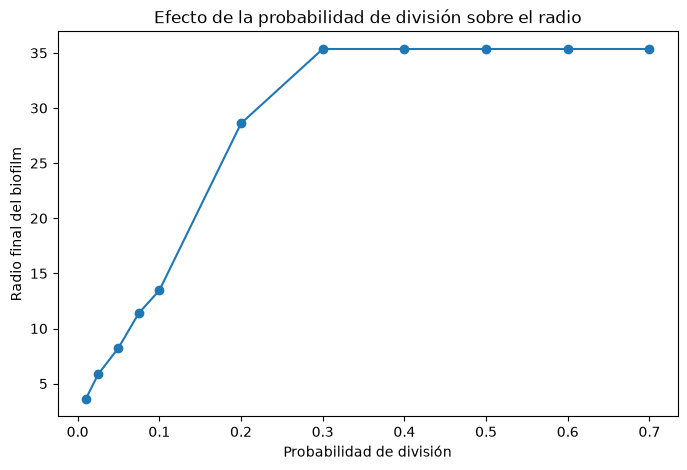

In [3]:
l = 50
b_0 = 5
steps = 100
div_prob_values = [0.01, 0.025, 0.05, 0.075, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

lattice = np.zeros((l, l), dtype=int)
center = l // 2

@njit
def get_neighbors(x, y):
    neighbors = []
    if x > 0:
        neighbors.append((x - 1, y))
    if x < l - 1:
        neighbors.append((x + 1, y))
    if y > 0:
        neighbors.append((x, y - 1))
    if y < l - 1:
        neighbors.append((x, y + 1))
    return neighbors

@njit
def calculate_radius(lattice):
    bacteria_positions = np.argwhere(lattice == 1)

    if len(bacteria_positions) == 0:
        return 0

    distances = []

    for x, y in bacteria_positions:
        distance = np.sqrt((x - center)**2 + (y - center)**2)
        distances.append(distance)

    return max(distances)

final_radius = []


for div_prob in div_prob_values:
    lattice = np.zeros((l, l), dtype=int)
    blocked_bacteria = set()
    for i in range(b_0):

        x = center + random.randint(-2, 2)
        y = center + random.randint(-2, 2)

        while lattice[x, y] == 1:

            x = center + random.randint(-2, 2)
            y = center + random.randint(-2, 2)

        lattice[x, y] = 1

    for step in range(steps):
        bacteria_positions = list(zip(*np.where(lattice == 1)))
        random.shuffle(bacteria_positions)
        for x, y in bacteria_positions: 
                if (x, y) in blocked_bacteria:
                    continue
        
                neighbors = get_neighbors(x, y)
        
                free_pos = [(nx, ny) for nx, ny in neighbors if lattice[nx, ny] == 0]
                if len(free_pos) == 0:
                    blocked_bacteria.add((x, y))
                    continue
                
                if random.random() < div_prob:
                    daughter_x, daughter_y = random.choice(free_pos)
                    lattice[daughter_x, daughter_y] = 1
                    
    radius = calculate_radius(lattice)
    final_radius.append(radius)

plt.figure(figsize=(8, 5))

plt.plot(div_prob_values, final_radius, marker="o")

plt.xlabel("Probabilidad de división")
plt.ylabel("Radio final del biofilm")
plt.title("Efecto de la probabilidad de división sobre el radio")

plt.show()


**COPY-NUMBER**

Los modelos dinámicos de plásmidos dentro de huéspedes bacterianos asumen que la segregación aleatória de plásmidos puede ser descrita por una distribución binomial, $B(n,p)$, en la que $n$ es una variable que denota el copy-number del plásmido de la célula madre y $p$ la probabilidad de éxito. 

Si se asume que hay la misma probabilidad de que cada plásmido pueda ser heredado por cada célula hija, $p = 0.5$, por lo que la probabilidad de producir una célula hija sin plásmido es de $2^{1-n}$.

Los plásmidos controlan su propia replicación para coexistir de forma estable con sus huéspedes. Por esto, el copy-number de un plásmido suele ser fijo y depender del huésped en el que esté y de las condiciones de crecimiento celular. De media hay un evento de replicación de plásmidos por ciclo celular. 

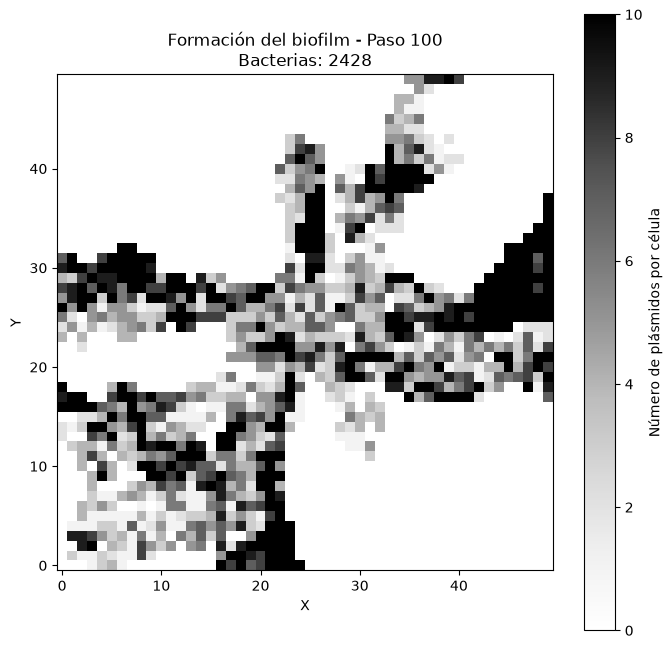

In [33]:
l = 50
b_0 = 10
div_prob = 0.3
steps = 100
copy_number = 5


lattice = np.zeros((l, l), dtype=int)
center = l // 2

for i in range(b_0):
    x = center + random.randint(-2, 2)
    y = center + random.randint(-2, 2)
    while lattice[x, y] == 1:
        x = center + random.randint(-2, 2)
        y = center + random.randint(-2, 2)
    lattice[x, y] = 1

plasmids = []

for x, y in zip(*np.where(lattice == 1)):
    for i in range(copy_number):
        plasmids.append({"x": x, "y": y})


@njit
def get_neighbors(x, y):
    neighbors = []
    if x > 0:
        neighbors.append((x - 1, y))
    if x < l - 1:
        neighbors.append((x + 1, y))
    if y > 0:
        neighbors.append((x, y - 1))
    if y < l - 1:
        neighbors.append((x, y + 1))
    return neighbors

lattice_history = []
blocked_bacteria = set()
copy_number_history = []

for step in range(steps + 1):
    clear_output(wait=True)
    lattice_history.append(lattice.copy())
    plasmid_lattice = np.zeros((l, l), dtype=int)
    for plasmid in plasmids:
        plasmid_lattice[plasmid["x"], plasmid["y"]] += 1

    total_plasmids = len(plasmids)
    total_bacteria = np.sum(lattice)
    copy_number_history.append(total_plasmids / total_bacteria)

    plt.figure(figsize=(8, 8))

    plt.imshow(plasmid_lattice, origin="lower", cmap="Greys", vmin=0, vmax= 2*copy_number)

    plt.xlim(-0.5, l - 0.5)
    plt.ylim(-0.5, l - 0.5)

    plt.colorbar(label="Número de plásmidos por célula")

    plt.title( 
        f"Formación del biofilm - Paso {step}\n" 
        f"Bacterias: {np.sum(lattice)}" 
    ) 
    plt.xlabel("X") 
    plt.ylabel("Y") 
    plt.show()

    time.sleep(0.01)
    if step == steps:
        break

    bacteria_positions = list(zip(*np.where(lattice == 1))) 
    random.shuffle(bacteria_positions) 
    for x, y in bacteria_positions: 
        if (x, y) in blocked_bacteria:
            continue

        neighbors = get_neighbors(x, y)

        free_pos = [(nx, ny) for nx, ny in neighbors if lattice[nx, ny] == 0]
        if len(free_pos) == 0:
            blocked_bacteria.add((x, y))
            continue
        if random.random() < div_prob:
            daughter_x, daughter_y = random.choice(free_pos)
            lattice[daughter_x, daughter_y] = 1
            
            plasmids_bacteria = [p for p in plasmids if p["x"] == x and p["y"] == y]
            duplicated_plasmids = []
            for p in plasmids_bacteria:
                duplicated_plasmids.append(p.copy())
                duplicated_plasmids.append(p.copy())
            plasmids = [p for p in plasmids if p["x"] != x or p["y"] != y]
            for plasmid in duplicated_plasmids:
                if random.random() < 0.5:
                    plasmid["x"] = daughter_x
                    plasmid["y"] = daughter_y
                else:
                    plasmid["x"] = x
                    plasmid["y"] = y
                plasmids.append(plasmid)


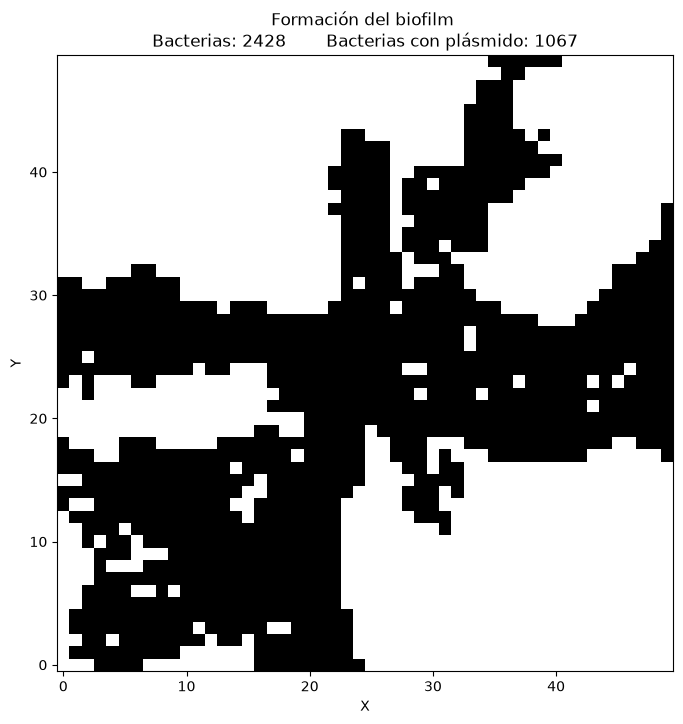

In [38]:
plasmid_presence = (plasmid_lattice > 0).astype(int)

plt.figure(figsize=(8, 8))

plt.imshow(plasmid_presence, origin="lower", cmap="Greys", vmin=0, vmax=1)

plt.xlim(-0.5, l - 0.5)
plt.ylim(-0.5, l - 0.5)

plt.title(f"Formación del biofilm \n" 
          f"Bacterias: {np.sum(lattice)}        "
          f"Bacterias con plásmido: {np.sum(plasmid_presence)}")

plt.xlabel("X")
plt.ylabel("Y")
plt.show()

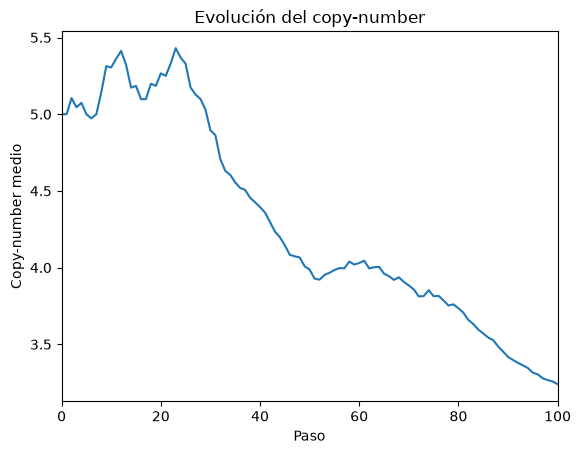

In [42]:
plt.plot(copy_number_history)
plt.xlim(left=0)
plt.xlim(right=steps)
plt.xlabel("Paso")
plt.ylabel("Copy-number medio")
plt.title("Evolución del copy-number")
plt.show()

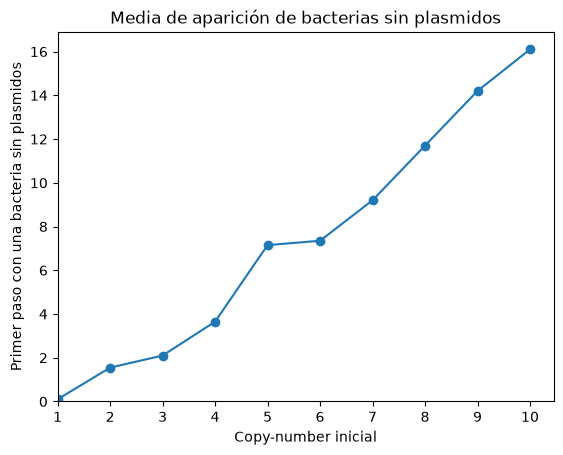

In [50]:
### Cuanto tiempo de media hasta que el 50% de las bacterias nuevas no tengan el plásmido?

copy_numbers = range(1, 11)
repetitions = 20
mean_first_plasmid_free = []

for copy_number in copy_numbers:
    first_steps = []

    for repetition in range(repetitions):

        lattice = np.zeros((l, l), dtype=int)
        center = l // 2

        for i in range(b_0):
            x = center + random.randint(-2, 2)
            y = center + random.randint(-2, 2)
            while lattice[x, y] == 1:
                x = center + random.randint(-2, 2)
                y = center + random.randint(-2, 2)
            lattice[x, y] = 1

        plasmids = []
        
        for x, y in zip(*np.where(lattice == 1)):
            for i in range(copy_number):
                plasmids.append({"x": x, "y": y})

        blocked_bacteria = set()
        first_step = None

        for step in range(steps):

            bacteria_positions = list(zip(*np.where(lattice == 1)))
            random.shuffle(bacteria_positions)

            for x, y in bacteria_positions:

                if (x, y) in blocked_bacteria:
                    continue

                neighbors = get_neighbors(x, y)
                free_pos = [(nx, ny) for nx, ny in neighbors if lattice[nx, ny] == 0]

                if len(free_pos) == 0:
                    blocked_bacteria.add((x, y))
                    continue

                if random.random() < div_prob:

                    daughter_x, daughter_y = random.choice(free_pos)
                    lattice[daughter_x, daughter_y] = 1

                    plasmids_bacteria = [p for p in plasmids if p["x"] == x and p["y"] == y]

                    duplicated_plasmids = []

                    for p in plasmids_bacteria:
                        duplicated_plasmids.append(p.copy())
                        duplicated_plasmids.append(p.copy())

                    plasmids = [p for p in plasmids if p["x"] != x or p["y"] != y]

                    for plasmid in duplicated_plasmids:

                        if random.random() < 0.5:
                            plasmid["x"] = daughter_x
                            plasmid["y"] = daughter_y
                        else:
                            plasmid["x"] = x
                            plasmid["y"] = y

                        plasmids.append(plasmid)
                    mother_plasmids = sum (1 for p in plasmids if p["x"] == x and p["y"] == y)
                    daughter_plasmids = sum(1 for p in plasmids if p["x"] == daughter_x and p["y"] == daughter_y)

                    if mother_plasmids == 0 or daughter_plasmids == 0:
                        first_step = step
                        break

            if first_step is not None:
                break

        if first_step is not None:
            first_steps.append(first_step)

    if len(first_steps) > 0:
        mean_first_plasmid_free.append(np.mean(first_steps))
    else:
        mean_first_plasmid_free.append(np.nan)
        

plt.plot(copy_numbers, mean_first_plasmid_free, marker="o")
plt.xlabel("Copy-number inicial")
plt.ylabel("Primer paso con una bacteria sin plasmidos")
plt.title("Media de aparición de bacterias sin plasmidos")
plt.xticks(list(copy_numbers))
plt.xlim(left=1)
plt.ylim(bottom=0)
plt.show()

**FORMACIÓN DEL BIOFILM (2 BACTERIAS) - NEUTRALISMO**

*time-lapse*

Se ha de arreglar. No es esto. (IGNORAR)

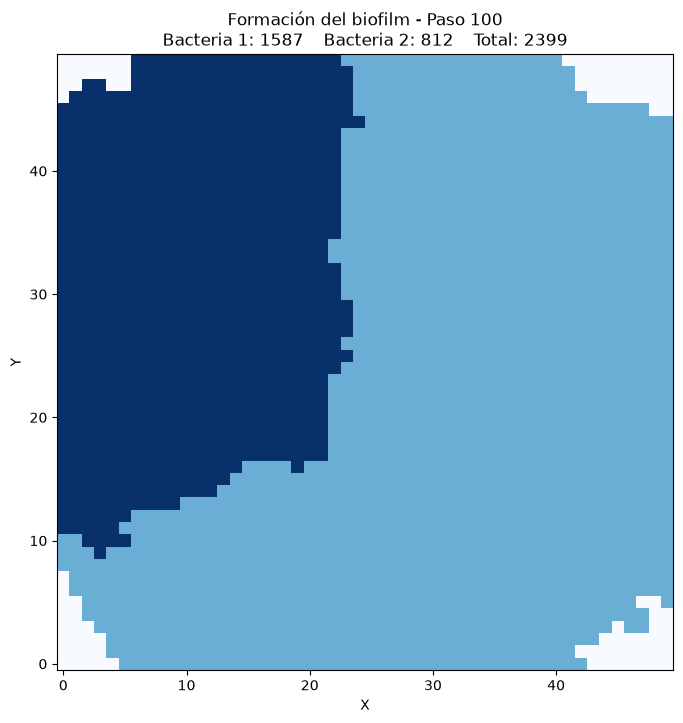

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import display, clear_output
import time

l = 50
b_0 = 6
div_prob = 0.3
steps = 100

lattice = np.zeros((l, l), dtype=int)
center = l // 2

for i in range(b_0):
    x = center + random.randint(-2, 2)
    y = center + random.randint(-2, 2)
    while lattice[x, y] != 0:
        x = center + random.randint(-2, 2)
        y = center + random.randint(-2, 2)
    if random.random() < 0.5:
        lattice[x, y] = 1
    else:
        lattice[x, y] = 2

def get_neighbors(x, y):
    neighbors = []
    if x > 0:
        neighbors.append((x - 1, y))
    if x < l - 1:
        neighbors.append((x + 1, y))
    if y > 0:
        neighbors.append((x, y - 1))
    if y < l - 1:
        neighbors.append((x, y + 1))
    return neighbors
    

def divide_bacterium(x, y):
    bacteria_type = lattice[x, y]
    neighbors = get_neighbors(x, y)
    free_pos = [(nx, ny) for nx, ny in neighbors if lattice[nx, ny] == 0]
    if len(free_pos) == 0:
        return

    daughter_x, daughter_y = random.choice(free_pos)

    lattice[daughter_x, daughter_y] = bacteria_type


for step in range(steps + 1): 
    clear_output(wait=True)

    bacteria_1 = np.sum(lattice == 1)
    bacteria_2 = np.sum(lattice == 2)
    total_bacteria = bacteria_1 + bacteria_2

    plt.figure(figsize=(8, 8))

    plt.imshow(lattice, origin="lower", cmap="Blues", vmin=0, vmax=2)

    plt.xlim(-0.5, l - 0.5)
    plt.ylim(-0.5, l - 0.5)

    plt.title( 
        f"Formación del biofilm - Paso {step}\n" 
        f"Bacteria 1: {bacteria_1}    "
        f"Bacteria 2: {bacteria_2}    "
        f"Total: {total_bacteria}" 
    ) 
    plt.xlabel("X") 
    plt.ylabel("Y") 
    plt.show()

    time.sleep(0.1)
    if step == steps:
        break

    bacteria_positions = list(zip(*np.where(lattice != 0))) 
    random.shuffle(bacteria_positions) 
    for x, y in bacteria_positions: 
        if lattice[x, y] != 0:
            if random.random() < div_prob:
                divide_bacterium(x, y)